# Experiment Results

Comprehensive evaluation across all 4 configs:
- **h_168_24** — 168/24 (hourly)
- **h_744_168** — 744/168 (hourly)
- **m_288_144** — 288/144 (10min)
- **m_1008_144** — 1008/144 (10min)

**Outline:**
1. Average MASE (Pooled)
2. Average MASE Rank (Pooled)
3. Average MASE Rank (Per Config)
4. Statistical Significance (Per Config, Per Benchmark)
5. Skill Score (Pooled, Per Benchmark)
6. Skill Score (Pooled, Per Config)
7. Skill Score (Per Config, Per Benchmark)
8. Pairwise Win Rate (Pooled)
9. Pairwise Win Rate (Per Config)
10. Pairwise Skill Score (Pooled)
11. Pairwise Skill Score (Per Config, Per Benchmark)
12. Performance by Aggregation Level (Pooled)
13. Inference Time (Per Config)
14. Easiest / Hardest Series (Per Config)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import gmean, friedmanchisquare, rankdata, wilcoxon
from statsmodels.stats.multitest import multipletests
import scikit_posthocs as sp

from result_exploration.analysis import (
    load_all_results, load_all_results_multi_config, load_timing_data,
    compute_average_rank, compute_pairwise_wins, compute_pairwise_skill,
    EXPERIMENT_CONFIGS, CONFIG_META,
    BENCHMARKS, MODEL_ORDER, AGG_LEVEL_ORDER,
    BENCH_LABELS, MODEL_LABELS,
)
from result_exploration.plots import plot_pairwise_heatmap, plot_speed_comparison, plot_agg_level_breakdown

METRIC = "mase"
CLIP_LO, CLIP_HI = 1e-2, 100
BASELINE = "seasonal_naive"
ALL_CONFIGS = list(EXPERIMENT_CONFIGS.keys())

GRAPH_DIR = Path("result_exploration/graphs")
GRAPH_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
def _highlight_rank_extremes(s):
    vals = pd.to_numeric(s, errors="coerce")
    valid = vals.dropna()
    styles = [""] * len(s)
    if len(valid) < 2:
        return styles
    best = valid.min()
    worst = valid.max()
    for i, v in enumerate(vals):
        if v == best:
            styles[i] = "background-color: #f59e0b; color: #000; font-weight: bold"
        elif v == worst:
            styles[i] = "background-color: #ef4444; color: #fff; font-weight: bold"
    return styles


def _highlight_skill(s):
    vals = pd.to_numeric(s, errors="coerce")
    valid = vals.dropna()
    styles = [""] * len(s)
    if len(valid) < 2:
        return styles
    best_idx = valid.idxmax()
    worst_idx = valid.idxmin()
    for i, idx in enumerate(s.index):
        label = idx if isinstance(idx, str) else s.index[i]
        if idx == best_idx:
            styles[i] = "background-color: #f59e0b; color: #000; font-weight: bold"
        elif idx == worst_idx:
            styles[i] = "background-color: #ef4444; color: #fff; font-weight: bold"
        elif label == MODEL_LABELS.get(BASELINE, BASELINE):
            styles[i] = "background-color: #dbeafe; color: #000"
    return styles


def skill_score(df, metric, group_cols):
    baseline = df.loc[df["model"] == BASELINE, ["id", "agg_level", "benchmark", metric]].rename(columns={metric: "baseline"})
    merged = df.merge(baseline, on=["id", "agg_level", "benchmark"])
    merged["ratio"] = np.clip(merged[metric] / merged["baseline"], CLIP_LO, CLIP_HI)
    merged = merged.dropna(subset=["ratio"])
    merged = merged[np.isfinite(merged["ratio"])]
    scores = merged.groupby(group_cols)["ratio"].apply(lambda x: 1 - gmean(x)).reset_index()
    scores.columns = [*group_cols, "skill_score"]
    return scores

In [3]:
results = {}
for config in ALL_CONFIGS:
    results[config] = load_all_results(runs=EXPERIMENT_CONFIGS[config], metrics=[METRIC])
    print(f"{config}: {len(results[config])} rows, {results[config]['model'].nunique()} models")

df_all = load_all_results_multi_config(metrics=[METRIC])

h_168_24: 2630 rows, 10 models
h_744_168: 2630 rows, 10 models
m_288_144: 2690 rows, 10 models
m_1008_144: 2690 rows, 10 models


## 1. Average MASE (Pooled)

Mean MASE per model, pooling all series across all 4 configs. Per-benchmark columns pool series from all configs for that benchmark.

In [4]:
df_pool = pd.concat([results[c] for c in ALL_CONFIGS], ignore_index=True)
n_series = df_pool.groupby("model")[METRIC].count().iloc[0]

avg_mase = df_pool.groupby(["model", "benchmark"])[METRIC].mean().unstack("benchmark")
std_mase = df_pool.groupby(["model", "benchmark"])[METRIC].std().unstack("benchmark")
avg_mase = avg_mase.reindex(index=[m for m in MODEL_ORDER if m in avg_mase.index])
std_mase = std_mase.reindex(index=avg_mase.index)
avg_mase = avg_mase[[b for b in BENCHMARKS if b in avg_mase.columns]]
std_mase = std_mase[[b for b in BENCHMARKS if b in std_mase.columns]]
avg_mase[f"avg (n={n_series})"] = df_pool.groupby("model")[METRIC].mean()
std_mase[f"avg (n={n_series})"] = df_pool.groupby("model")[METRIC].std()

combined = avg_mase.copy()
for col in combined.columns:
    combined[col] = avg_mase[col].map("{:.3f}".format) + " ± " + std_mase[col].map("{:.3f}".format)

combined = combined.loc[avg_mase.sort_values(f"avg (n={n_series})").index]
combined.index = [MODEL_LABELS.get(m, m) for m in combined.index]
combined.columns = [BENCH_LABELS.get(c, c) for c in combined.columns]

display(combined)

,Drift,Seasonal,Periodic Spaces,Workers,Random,avg (n=1064)
Chronos-2,0.703 ± 1.631,0.571 ± 0.414,0.608 ± 1.706,0.425 ± 0.247,0.506 ± 0.278,0.582 ± 1.049
TimesFM,0.718 ± 1.716,0.591 ± 0.398,0.600 ± 1.645,0.420 ± 0.245,0.501 ± 0.265,0.589 ± 1.076
Moirai,0.729 ± 1.755,0.621 ± 0.401,0.595 ± 1.631,0.419 ± 0.246,0.503 ± 0.266,0.601 ± 1.092
TTM,0.818 ± 1.597,0.669 ± 0.467,0.752 ± 1.777,0.608 ± 0.348,0.619 ± 0.336,0.701 ± 1.058
Seasonal Naive,0.938 ± 1.778,0.788 ± 0.442,0.874 ± 1.708,0.739 ± 0.412,0.793 ± 0.445,0.835 ± 1.134
Prophet,1.065 ± 2.366,0.847 ± 0.697,0.997 ± 2.217,0.904 ± 0.567,0.796 ± 0.525,0.915 ± 1.509
GRU,0.915 ± 2.325,0.837 ± 0.698,2.605 ± 6.205,0.913 ± 2.248,0.659 ± 0.821,0.988 ± 2.482
SARIMA,1.042 ± 2.414,0.801 ± 0.613,0.978 ± 2.425,0.796 ± 0.495,1.425 ± 9.544,1.040 ± 4.991
GRU-FCN,1.233 ± 3.503,0.978 ± 1.484,0.698 ± 1.765,0.530 ± 0.475,1.273 ± 4.660,1.055 ± 3.133
LSTM,0.988 ± 2.514,0.817 ± 0.791,3.066 ± 7.150,1.173 ± 3.741,0.703 ± 1.319,1.082 ± 2.980


## 2. Average MASE Rank (Pooled)

Per-benchmark average ranks computed within each config, then averaged across configs. The `avg_rank` column is the mean across the 5 benchmark columns (equal weight per benchmark, not per series).

In [5]:
per_config_ranks = {}
for config in ALL_CONFIGS:
    rank_df = compute_average_rank(results[config], METRIC).set_index("model")
    bench_cols = [b for b in BENCHMARKS if b in rank_df.columns]
    per_config_ranks[config] = rank_df[bench_cols]

all_models = sorted(set().union(*(df.index for df in per_config_ranks.values())), key=lambda m: MODEL_ORDER.index(m) if m in MODEL_ORDER else 99)

pooled = pd.DataFrame(index=all_models)
for bench in BENCHMARKS:
    bench_vals = []
    for config in ALL_CONFIGS:
        if bench in per_config_ranks[config].columns:
            bench_vals.append(per_config_ranks[config][bench])
    if bench_vals:
        pooled[bench] = pd.concat(bench_vals, axis=1).mean(axis=1)

pooled["avg_rank (avg of benchmarks)"] = pooled.mean(axis=1)
pooled = pooled.sort_values("avg_rank (avg of benchmarks)")
pooled.index = [MODEL_LABELS.get(m, m) for m in pooled.index]
pooled.columns = [BENCH_LABELS.get(c, c) for c in pooled.columns]

display(
    pooled.style
    .format(precision=2)
    .apply(_highlight_rank_extremes)
)

,Drift,Seasonal,Periodic Spaces,Workers,Random,avg_rank (avg of benchmarks)
TimesFM,2.67,2.68,3.14,3.50,2.77,2.95
Chronos-2,2.15,1.88,4.42,4.58,3.02,3.21
Moirai,3.39,4.22,4.63,4.18,3.21,3.93
GRU,5.75,6.32,4.72,3.03,4.76,4.91
GRU-FCN,5.78,5.17,4.84,4.05,5.48,5.06
LSTM,6.44,6.54,4.95,3.44,5.53,5.38
TTM,5.49,4.96,6.44,6.48,5.61,5.80
SARIMA,7.42,7.24,6.91,8.27,7.82,7.53
Seasonal Naive,7.82,7.86,7.20,8.14,8.71,7.94
Prophet,8.10,8.13,7.75,9.33,8.10,8.28


Average rank pooled across all series and configs.

In [6]:
df_pool_cfg = pd.concat(
    [results[c].assign(config=c) for c in ALL_CONFIGS], ignore_index=True
)
pooled_rank = df_pool_cfg.pivot_table(
    index=["config", "id", "agg_level", "benchmark"], columns="model", values=METRIC
)
pooled_rank = pooled_rank.rank(axis=1)
avg_pooled_rank = pooled_rank.mean().sort_values()
avg_pooled_rank.index = [MODEL_LABELS.get(m, m) for m in avg_pooled_rank.index]
n = len(pooled_rank)

display(
    avg_pooled_rank.to_frame(f"avg rank (n={n})")
    .style
    .format(precision=2)
    .apply(_highlight_rank_extremes)
)

,avg rank (n=1064)
Chronos-2,2.73
TimesFM,2.82
Moirai,3.77
GRU-FCN,5.27
GRU,5.30
TTM,5.56
LSTM,5.82
SARIMA,7.50
Seasonal Naive,8.03
Prophet,8.20


Average rank per model within each config (averaged across benchmarks within each config).

In [7]:
pooled_rank_by_config = pd.DataFrame()
for config in ALL_CONFIGS:
    label = CONFIG_META[config]["label"]
    rank_df = compute_average_rank(results[config], METRIC).set_index("model")
    bench_cols = [b for b in BENCHMARKS if b in rank_df.columns]
    pooled_rank_by_config[label] = rank_df[bench_cols].mean(axis=1)

pooled_rank_by_config = pooled_rank_by_config.reindex([m for m in MODEL_ORDER if m in pooled_rank_by_config.index])
pooled_rank_by_config["avg"] = pooled_rank_by_config.mean(axis=1)
pooled_rank_by_config = pooled_rank_by_config.sort_values("avg")
pooled_rank_by_config.index = [MODEL_LABELS.get(m, m) for m in pooled_rank_by_config.index]

display(
    pooled_rank_by_config.style
    .format(precision=2)
    .apply(_highlight_rank_extremes)
)

,168/24 (hourly),744/168 (hourly),288/144 (10min),1008/144 (10min),avg
TimesFM,3.19,2.79,2.62,3.21,2.95
Chronos-2,3.65,3.17,2.96,3.05,3.21
Moirai,4.19,3.21,3.85,4.45,3.93
GRU,4.31,5.67,5.77,3.91,4.91
GRU-FCN,5.29,5.39,4.92,4.65,5.06
LSTM,4.80,6.29,5.88,4.54,5.38
TTM,3.85,6.73,5.98,6.62,5.80
SARIMA,9.06,6.61,7.05,7.42,7.53
Seasonal Naive,8.13,6.94,8.23,8.47,7.94
Prophet,8.53,8.20,7.74,8.68,8.28


## 3. Average MASE Rank (Per Config)

In [8]:
for config in ALL_CONFIGS:
    label = CONFIG_META[config]["label"]
    rank_df = compute_average_rank(results[config], METRIC)
    rank_df = rank_df.set_index("model")
    rank_df.index = [MODEL_LABELS.get(m, m) for m in rank_df.index]
    rank_df.columns = [BENCH_LABELS.get(c, c) for c in rank_df.columns]
    num_cols = [c for c in rank_df.columns if c not in ["rank"]]

    print(f"\n{'='*60}")
    print(f"  Average MASE Rank — {label}")
    print(f"{'='*60}")
    display(
        rank_df.style
        .format(precision=2)
        .apply(_highlight_rank_extremes, subset=num_cols)
    )


  Average MASE Rank — 168/24 (hourly)


,Drift,Seasonal,Periodic Spaces,Workers,Random,avg_rank,rank
TimesFM,2.77,2.67,3.92,3.48,3.11,3.19,1
Chronos-2,2.33,2.00,5.04,5.00,3.89,3.65,2
TTM,3.59,4.12,4.00,3.88,3.68,3.85,3
Moirai,3.63,3.97,5.44,4.60,3.30,4.19,4
GRU,5.35,5.88,3.36,2.72,4.24,4.31,5
LSTM,6.67,6.44,3.04,2.44,5.40,4.80,6
GRU-FCN,5.07,3.80,5.68,6.56,5.37,5.29,7
Seasonal Naive,8.47,8.32,7.28,7.76,8.83,8.13,8
Prophet,8.43,9.05,8.20,8.76,8.19,8.53,9
SARIMA,8.71,8.75,9.04,9.80,9.00,9.06,10



  Average MASE Rank — 744/168 (hourly)


,Drift,Seasonal,Periodic Spaces,Workers,Random,avg_rank,rank
TimesFM,2.33,1.85,3.30,3.92,2.52,2.79,1
Chronos-2,2.29,2.19,4.04,4.92,2.40,3.17,2
Moirai,2.47,2.51,4.32,3.96,2.81,3.21,3
GRU-FCN,7.19,7.55,3.04,1.88,7.32,5.39,4
GRU,7.41,8.08,4.12,2.28,6.48,5.67,5
LSTM,7.97,8.12,5.08,4.12,6.17,6.29,6
SARIMA,6.15,5.68,7.02,7.44,6.75,6.61,7
TTM,6.16,5.56,7.96,8.32,5.63,6.73,8
Seasonal Naive,5.33,6.25,7.26,8.40,7.46,6.94,9
Prophet,7.69,7.21,8.86,9.76,7.46,8.20,10



  Average MASE Rank — 288/144 (10min)


,Drift,Seasonal,Periodic Spaces,Workers,Random,avg_rank,rank
TimesFM,3.04,3.57,1.58,2.12,2.78,2.62,1
Chronos-2,2.21,2.16,3.68,3.80,2.96,2.96,2
Moirai,3.77,5.37,3.72,3.12,3.28,3.85,3
GRU-FCN,5.44,4.80,5.72,4.04,4.61,4.92,4
GRU,5.05,5.64,8.28,5.52,4.33,5.77,5
LSTM,5.29,5.09,8.36,5.48,5.19,5.88,6
TTM,5.95,5.09,6.12,6.36,6.39,5.98,7
SARIMA,7.44,6.96,5.34,7.68,7.83,7.05,8
Prophet,8.07,7.95,5.46,8.92,8.29,7.74,9
Seasonal Naive,8.73,8.36,6.74,7.96,9.35,8.23,10



  Average MASE Rank — 1008/144 (10min)


,Drift,Seasonal,Periodic Spaces,Workers,Random,avg_rank,rank
Chronos-2,1.75,1.17,4.92,4.60,2.83,3.05,1
TimesFM,2.53,2.63,3.74,4.48,2.65,3.21,2
GRU,5.17,5.67,3.12,1.60,3.99,3.91,3
Moirai,3.69,5.03,5.04,5.04,3.43,4.45,4
LSTM,5.83,6.51,3.32,1.72,5.35,4.54,5
GRU-FCN,5.41,4.55,4.92,3.72,4.64,4.65,6
TTM,6.28,5.05,7.68,7.36,6.72,6.62,7
SARIMA,7.40,7.57,6.26,8.16,7.72,7.42,8
Seasonal Naive,8.73,8.51,7.50,8.44,9.19,8.47,9
Prophet,8.20,8.32,8.50,9.88,8.48,8.68,10


## 4. Statistical Significance (Per Config, Per Benchmark)

Friedman test with Nemenyi post-hoc, run per benchmark within each config.
Per-benchmark testing avoids pooling heterogeneous series types into a single test.
Holm correction applied across the 5 Friedman p-values within each config.


  Friedman + Nemenyi — 168/24 (hourly)


Benchmark,n,k,chi2,p (raw),p (Holm),H0 rejected
Drift,75,10,440.63,2.89e-89,1.16e-88,True
Seasonal,75,10,487.23,3.12e-99,1.56e-98,True
Periodic Spaces,25,10,106.87,6.37e-19,6.37e-19,True
Workers,25,10,164.20,9.96e-31,1.99e-30,True
Random,63,10,334.06,1.52e-66,4.57e-66,True



CD — MASE — Drift (168/24 (hourly))
Friedman p=1.16e-88 (Holm-corrected, significant), n=75
Saved: result_exploration/graphs/h_168_24/cd_diagrams/cd_drift.pdf


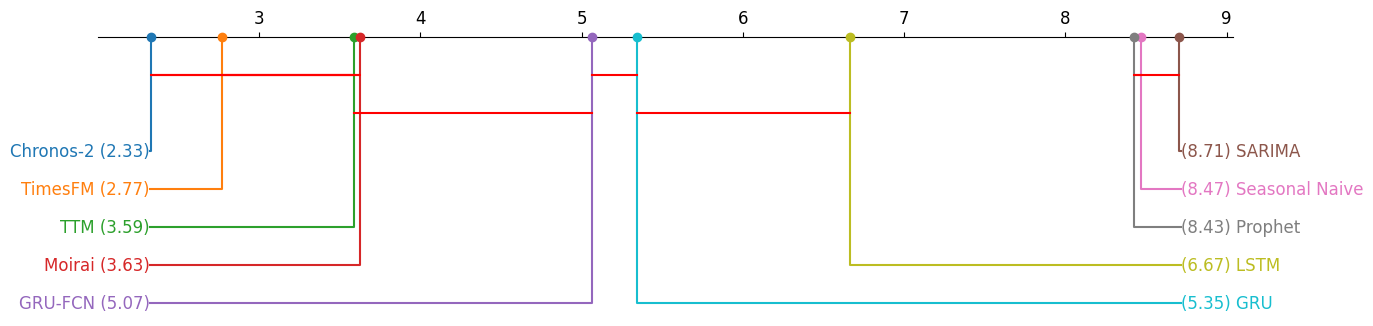


CD — MASE — Seasonal (168/24 (hourly))
Friedman p=1.56e-98 (Holm-corrected, significant), n=75
Saved: result_exploration/graphs/h_168_24/cd_diagrams/cd_seasonal.pdf


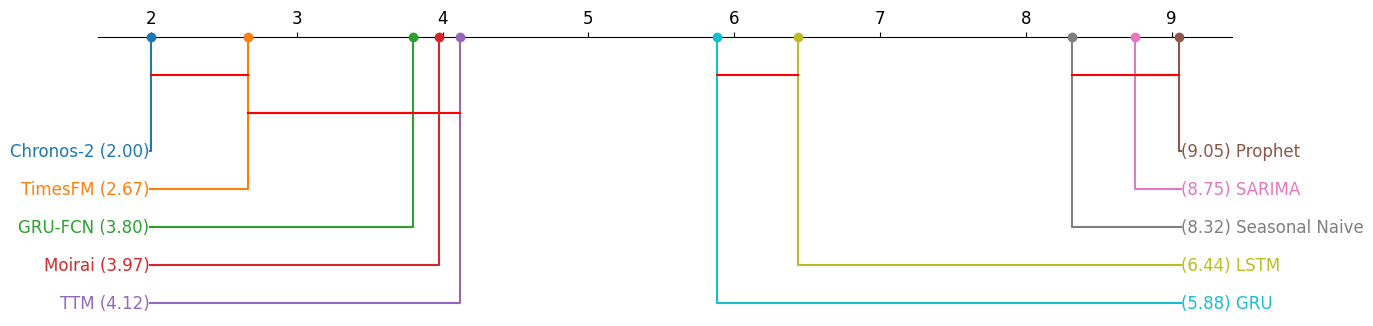


CD — MASE — Periodic Spaces (168/24 (hourly))
Friedman p=6.37e-19 (Holm-corrected, significant), n=25
Saved: result_exploration/graphs/h_168_24/cd_diagrams/cd_periodic_spaces.pdf


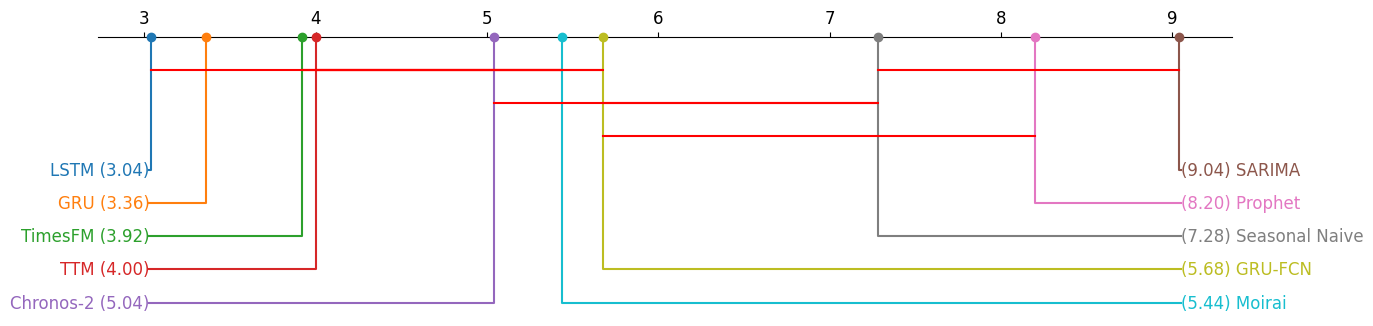


CD — MASE — Workers (168/24 (hourly))
Friedman p=1.99e-30 (Holm-corrected, significant), n=25
Saved: result_exploration/graphs/h_168_24/cd_diagrams/cd_workers.pdf


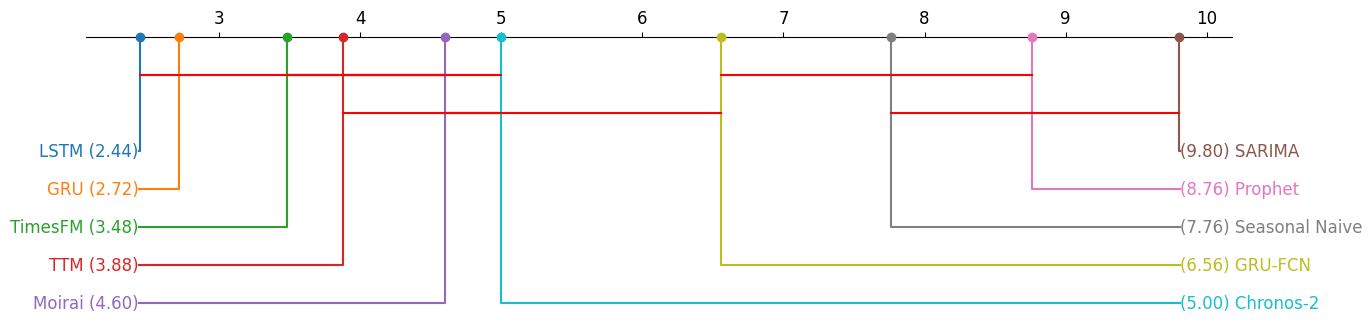


CD — MASE — Random (168/24 (hourly))
Friedman p=4.57e-66 (Holm-corrected, significant), n=63
Saved: result_exploration/graphs/h_168_24/cd_diagrams/cd_random.pdf


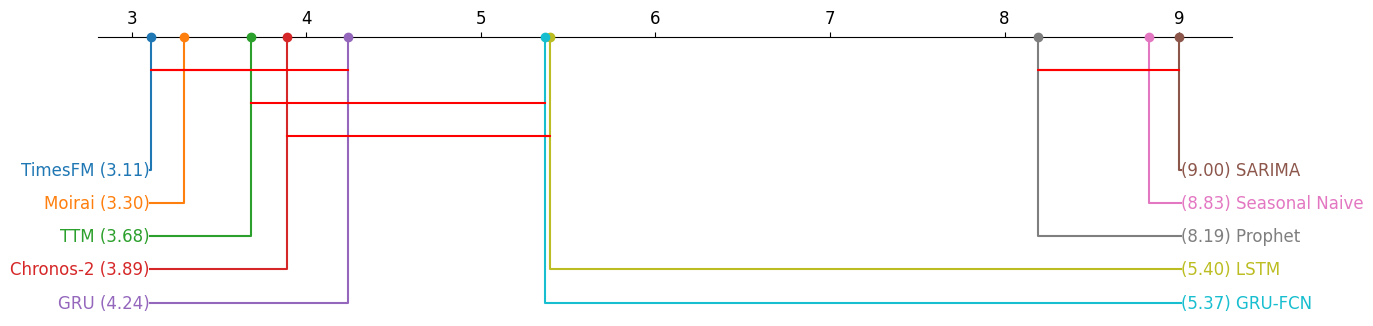


  Friedman + Nemenyi — 744/168 (hourly)


Benchmark,n,k,chi2,p (raw),p (Holm),H0 rejected
Drift,75,10,391.31,9.78e-79,3.91e-78,True
Seasonal,75,10,445.79,2.28e-90,1.14e-89,True
Periodic Spaces,25,10,107.82,4.09e-19,4.09e-19,True
Workers,25,10,187.79,1.20e-35,2.39e-35,True
Random,63,10,272.80,1.51e-53,4.53e-53,True



CD — MASE — Drift (744/168 (hourly))
Friedman p=3.91e-78 (Holm-corrected, significant), n=75
Saved: result_exploration/graphs/h_744_168/cd_diagrams/cd_drift.pdf


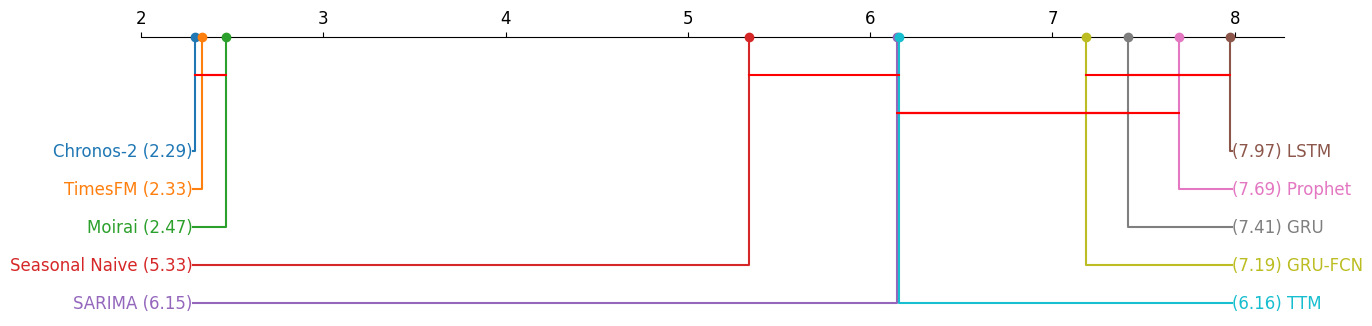


CD — MASE — Seasonal (744/168 (hourly))
Friedman p=1.14e-89 (Holm-corrected, significant), n=75
Saved: result_exploration/graphs/h_744_168/cd_diagrams/cd_seasonal.pdf


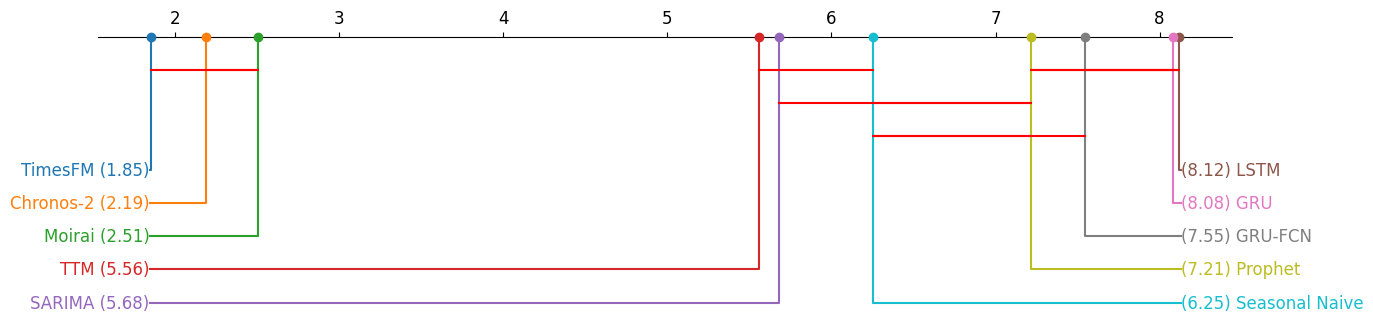


CD — MASE — Periodic Spaces (744/168 (hourly))
Friedman p=4.09e-19 (Holm-corrected, significant), n=25
Saved: result_exploration/graphs/h_744_168/cd_diagrams/cd_periodic_spaces.pdf


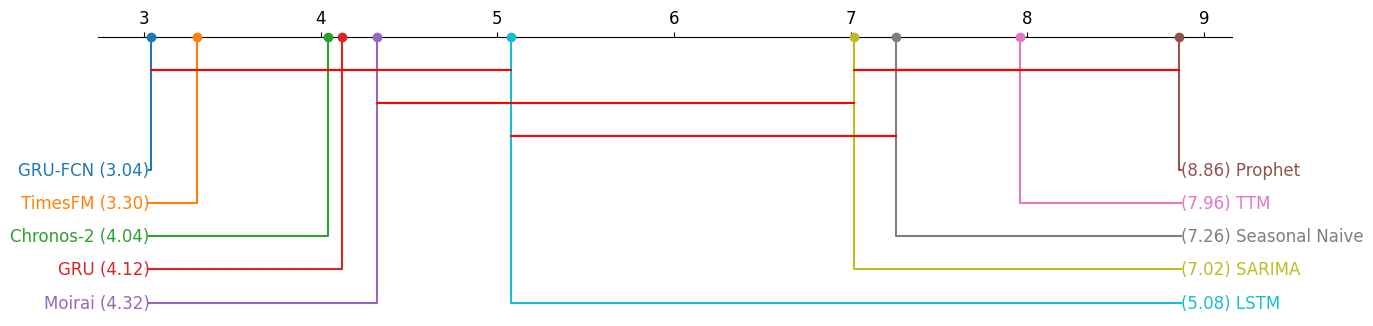


CD — MASE — Workers (744/168 (hourly))
Friedman p=2.39e-35 (Holm-corrected, significant), n=25
Saved: result_exploration/graphs/h_744_168/cd_diagrams/cd_workers.pdf


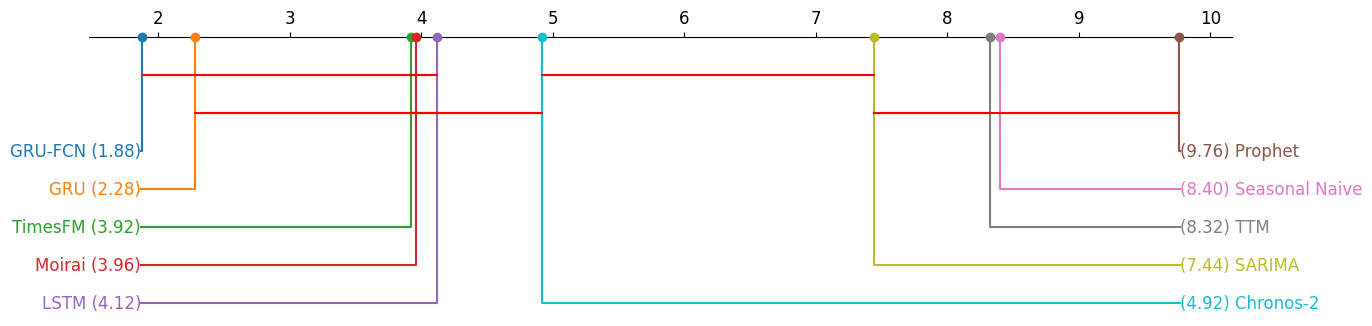


CD — MASE — Random (744/168 (hourly))
Friedman p=4.53e-53 (Holm-corrected, significant), n=63
Saved: result_exploration/graphs/h_744_168/cd_diagrams/cd_random.pdf


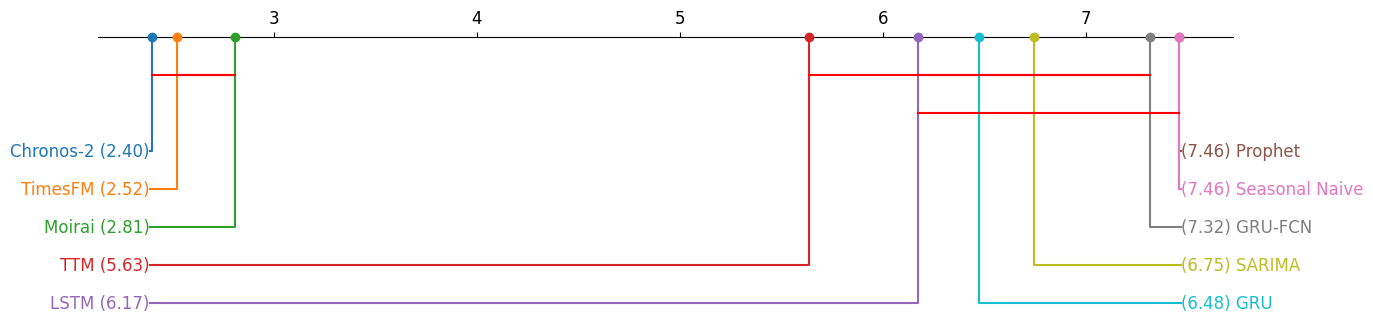


  Friedman + Nemenyi — 288/144 (10min)


Benchmark,n,k,chi2,p (raw),p (Holm),H0 rejected
Drift,75,10,336.16,5.45e-67,2.18e-66,True
Seasonal,75,10,261.99,2.92e-51,8.76e-51,True
Periodic Spaces,25,10,109.75,1.66e-19,1.66e-19,True
Workers,25,10,123.69,2.35e-22,4.70e-22,True
Random,69,10,375.23,2.62e-75,1.31e-74,True



CD — MASE — Drift (288/144 (10min))
Friedman p=2.18e-66 (Holm-corrected, significant), n=75
Saved: result_exploration/graphs/m_288_144/cd_diagrams/cd_drift.pdf


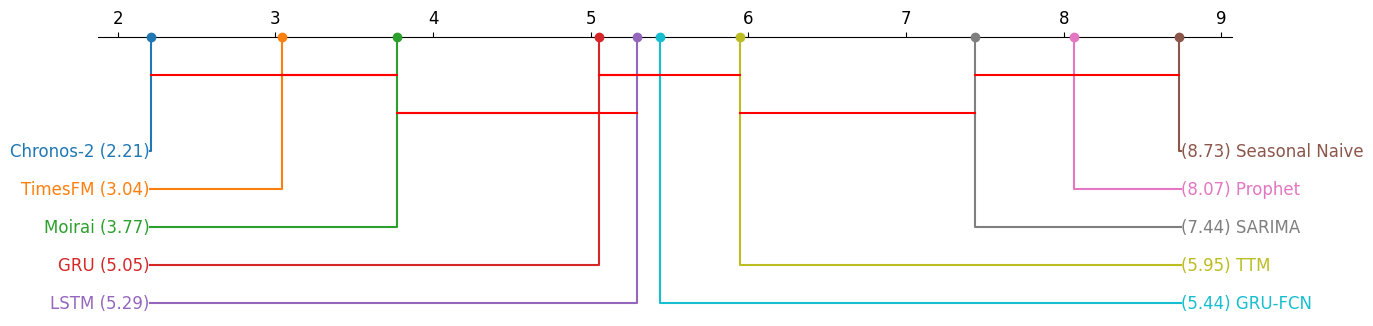


CD — MASE — Seasonal (288/144 (10min))
Friedman p=8.76e-51 (Holm-corrected, significant), n=75
Saved: result_exploration/graphs/m_288_144/cd_diagrams/cd_seasonal.pdf


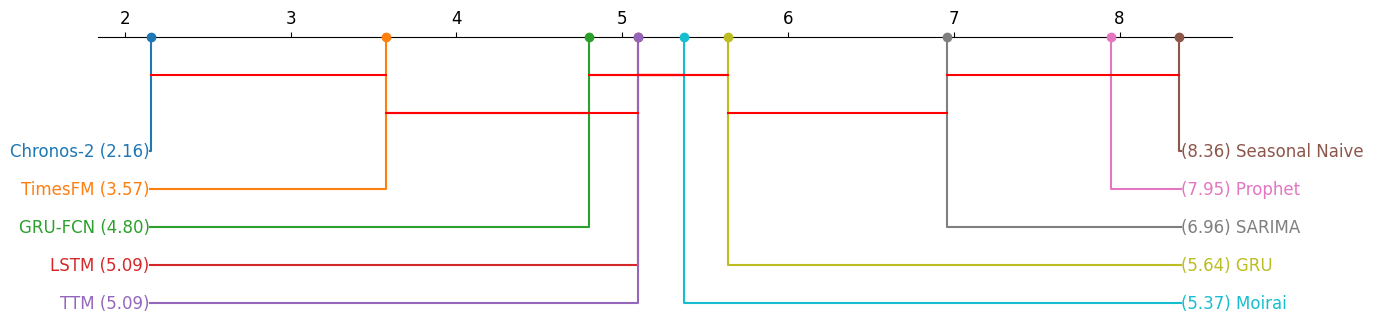


CD — MASE — Periodic Spaces (288/144 (10min))
Friedman p=1.66e-19 (Holm-corrected, significant), n=25
Saved: result_exploration/graphs/m_288_144/cd_diagrams/cd_periodic_spaces.pdf


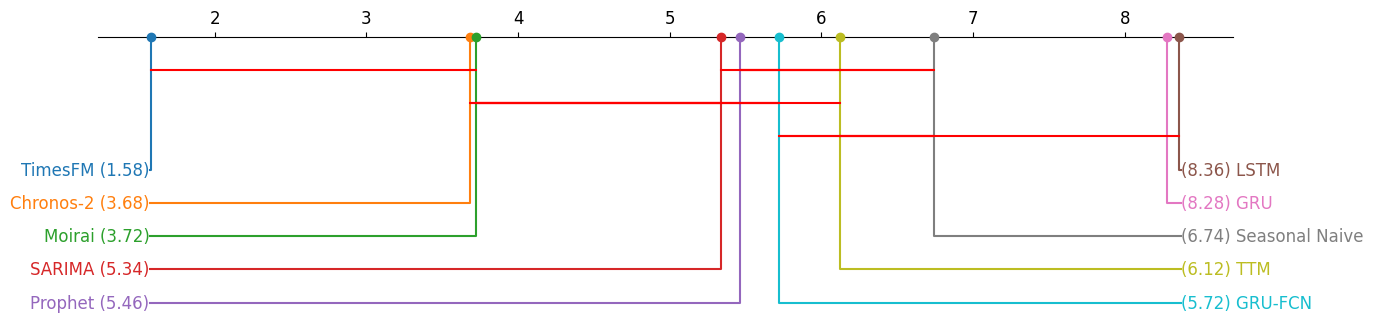


CD — MASE — Workers (288/144 (10min))
Friedman p=4.70e-22 (Holm-corrected, significant), n=25
Saved: result_exploration/graphs/m_288_144/cd_diagrams/cd_workers.pdf


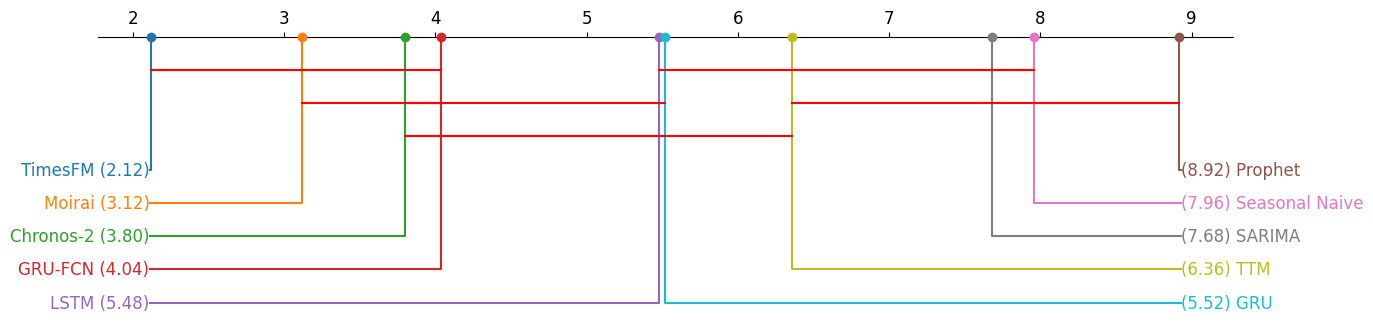


CD — MASE — Random (288/144 (10min))
Friedman p=1.31e-74 (Holm-corrected, significant), n=69
Saved: result_exploration/graphs/m_288_144/cd_diagrams/cd_random.pdf


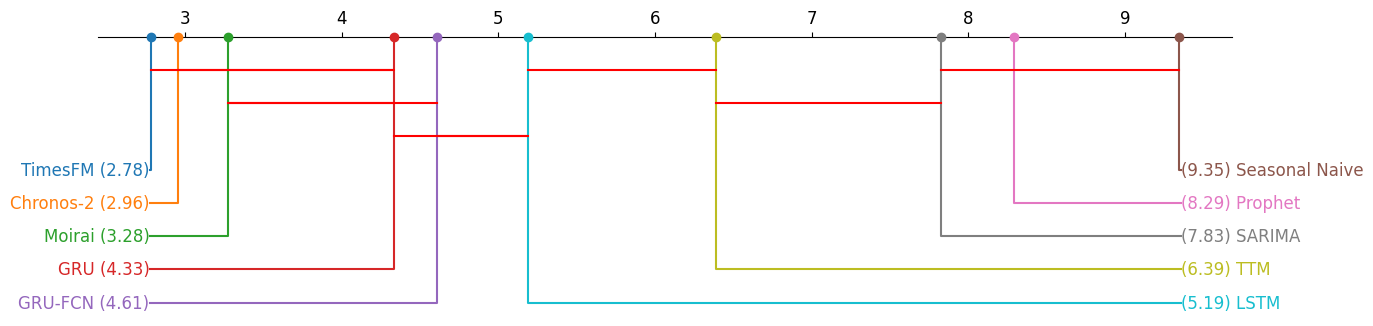


  Friedman + Nemenyi — 1008/144 (10min)


Benchmark,n,k,chi2,p (raw),p (Holm),H0 rejected
Drift,75,10,395.48,1.26e-79,5.05e-79,True
Seasonal,75,10,414.33,1.20e-83,5.98e-83,True
Periodic Spaces,25,10,90.36,1.38e-15,1.38e-15,True
Workers,25,10,199.34,4.55e-38,9.10e-38,True
Random,69,10,387.72,5.70e-78,1.71e-77,True



CD — MASE — Drift (1008/144 (10min))
Friedman p=5.05e-79 (Holm-corrected, significant), n=75
Saved: result_exploration/graphs/m_1008_144/cd_diagrams/cd_drift.pdf


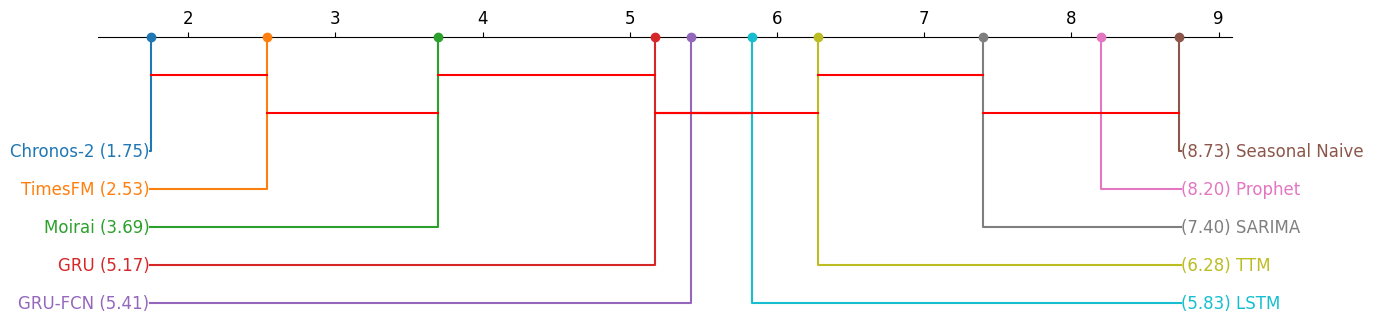


CD — MASE — Seasonal (1008/144 (10min))
Friedman p=5.98e-83 (Holm-corrected, significant), n=75
Saved: result_exploration/graphs/m_1008_144/cd_diagrams/cd_seasonal.pdf


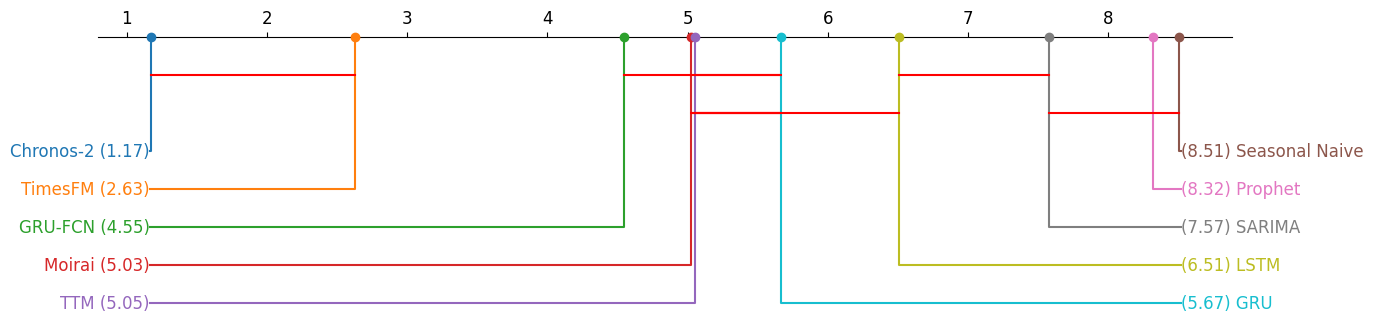


CD — MASE — Periodic Spaces (1008/144 (10min))
Friedman p=1.38e-15 (Holm-corrected, significant), n=25
Saved: result_exploration/graphs/m_1008_144/cd_diagrams/cd_periodic_spaces.pdf


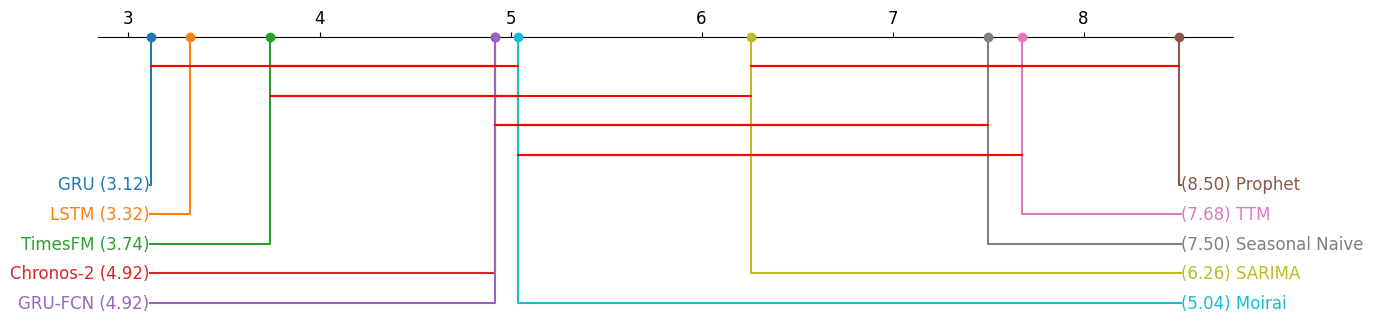


CD — MASE — Workers (1008/144 (10min))
Friedman p=9.10e-38 (Holm-corrected, significant), n=25
Saved: result_exploration/graphs/m_1008_144/cd_diagrams/cd_workers.pdf


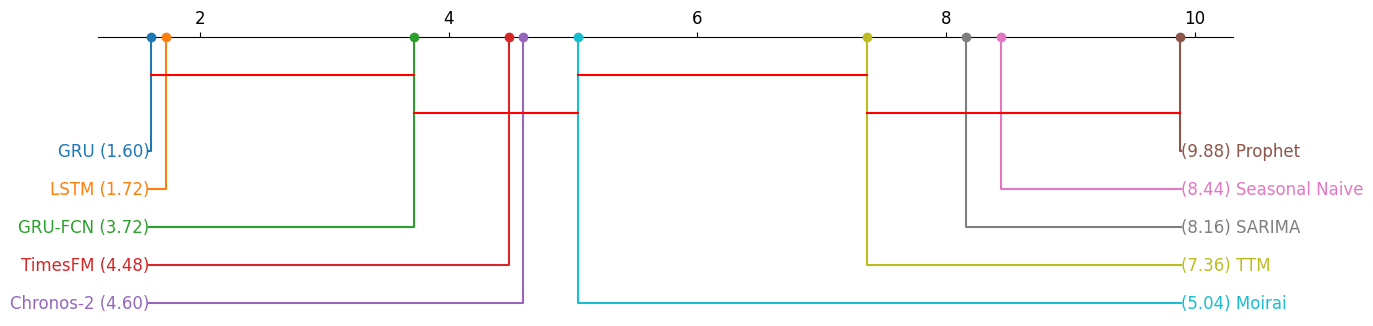


CD — MASE — Random (1008/144 (10min))
Friedman p=1.71e-77 (Holm-corrected, significant), n=69
Saved: result_exploration/graphs/m_1008_144/cd_diagrams/cd_random.pdf


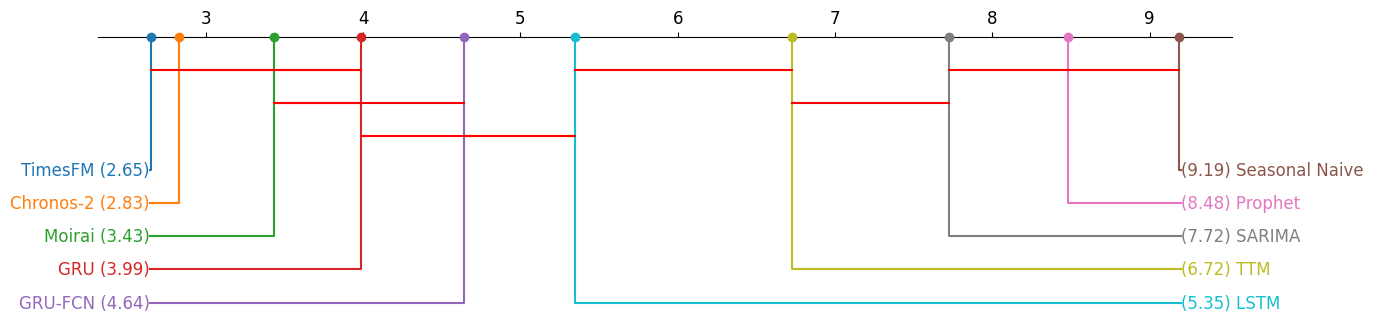

In [9]:
for config in ALL_CONFIGS:
    label = CONFIG_META[config]["label"]
    df = results[config]

    friedman_results = []
    for bench in BENCHMARKS:
        bench_df = df[df["benchmark"] == bench]
        if bench_df.empty:
            continue
        pivot = bench_df.pivot_table(index=["id", "agg_level"], columns="model", values=METRIC).dropna()
        models = [m for m in MODEL_ORDER if m in pivot.columns]
        pivot = pivot[models]
        if len(pivot) < 3 or len(models) < 3:
            continue
        stat, p = friedmanchisquare(*[pivot[m].values for m in models])
        friedman_results.append({"benchmark": bench, "stat": stat, "p": p, "n": len(pivot), "pivot": pivot, "models": models})

    raw_pvals = [r["p"] for r in friedman_results]
    rejected, corrected_pvals, _, _ = multipletests(raw_pvals, method="holm")
    for r, cp, rej in zip(friedman_results, corrected_pvals, rejected):
        r["p_holm"] = cp
        r["rejected"] = rej

    print(f"\n{'='*70}")
    print(f"  Friedman + Nemenyi — {label}")
    print(f"{'='*70}")

    summary = pd.DataFrame([
        {
            "Benchmark": BENCH_LABELS.get(r["benchmark"], r["benchmark"]),
            "n": r["n"],
            "k": len(r["models"]),
            "chi2": f"{r['stat']:.2f}",
            "p (raw)": f"{r['p']:.2e}",
            "p (Holm)": f"{r['p_holm']:.2e}",
            "H0 rejected": r["rejected"],
        }
        for r in friedman_results
    ])
    display(summary.style.hide(axis="index"))

    cd_dir = GRAPH_DIR / config / "cd_diagrams"
    cd_dir.mkdir(parents=True, exist_ok=True)

    for r in friedman_results:
        pivot = r["pivot"]
        models = r["models"]
        ranks = pivot.apply(lambda row: pd.Series(rankdata(row.values), index=row.index), axis=1)
        avg_ranks = ranks.mean()
        avg_ranks.index = [MODEL_LABELS.get(m, m) for m in avg_ranks.index]

        nemenyi = sp.posthoc_nemenyi_friedman(pivot.values)
        nemenyi.index = [MODEL_LABELS.get(m, m) for m in models]
        nemenyi.columns = [MODEL_LABELS.get(m, m) for m in models]

        sig_label = "significant" if r["rejected"] else "not significant"
        title_text = (
            f"CD — MASE — {BENCH_LABELS.get(r['benchmark'], r['benchmark'])} ({label})\n"
            f"Friedman p={r['p_holm']:.2e} (Holm-corrected, {sig_label}), n={r['n']}"
        )
        print(f"\n{title_text}")

        fig, ax = plt.subplots(figsize=(14, 3.5))
        sp.critical_difference_diagram(
            avg_ranks, nemenyi, ax=ax,
            label_fmt_left="{label} ({rank:.2f})",
            label_fmt_right="({rank:.2f}) {label}",
            label_props={"fontsize": 12},
            crossbar_props={"linewidth": 1.5, "color": "red"},
        )
        ax.set_title("")
        plt.tight_layout()

        bench_slug = r["benchmark"].replace(" ", "_")
        out = cd_dir / f"cd_{bench_slug}.pdf"
        fig.savefig(out, bbox_inches="tight")
        print(f"Saved: {out}")
        plt.show()

## 5. Skill Score (Pooled, Per Benchmark)

Skill scores computed within each config, then averaged across configs per benchmark. Last column is the mean across benchmarks.

In [10]:
pooled_skill_bench = pd.DataFrame()
for config in ALL_CONFIGS:
    df = results[config]
    per_bench = skill_score(df, METRIC, ["model", "benchmark"])
    pivot = per_bench.pivot(index="model", columns="benchmark", values="skill_score")
    pooled_skill_bench = pooled_skill_bench.add(pivot, fill_value=0) if not pooled_skill_bench.empty else pivot.copy()

pooled_skill_bench = pooled_skill_bench / len(ALL_CONFIGS) * 100
pooled_skill_bench = pooled_skill_bench.reindex(index=[m for m in MODEL_ORDER if m in pooled_skill_bench.index])
pooled_skill_bench = pooled_skill_bench[[b for b in BENCHMARKS if b in pooled_skill_bench.columns]]
pooled_skill_bench["avg"] = pooled_skill_bench.mean(axis=1)
pooled_skill_bench = pooled_skill_bench.sort_values("avg", ascending=False)
pooled_skill_bench.index = [MODEL_LABELS.get(m, m) for m in pooled_skill_bench.index]
pooled_skill_bench.columns = [BENCH_LABELS.get(c, c) for c in pooled_skill_bench.columns]

display(
    pooled_skill_bench.style
    .format("{:.1f}", na_rep="—")
    .apply(_highlight_skill)
)

,Drift,Seasonal,Periodic Spaces,Workers,Random,avg
TimesFM,28.3,26.2,42.3,44.2,36.8,35.5
Chronos-2,29.4,29.0,-35.7,43.4,36.4,20.5
Moirai,27.4,22.3,-33.7,44.3,36.6,19.4
Seasonal Naive,0.0,0.0,0.0,0.0,0.0,0.0
TTM,11.5,15.7,-76.1,16.4,20.8,-2.3
SARIMA,-0.7,0.8,-2.8,-8.1,-2.7,-2.7
GRU-FCN,-0.4,-0.5,-63.1,35.5,10.2,-3.6
Prophet,-6.6,-4.4,-14.4,-21.6,1.2,-9.2
GRU,10.3,-0.7,-333.6,27.3,25.4,-54.3
LSTM,5.0,1.3,-389.9,27.5,25.4,-66.1


## 6. Skill Score (Pooled, Per Config)

Average skill score per model within each config (columns). Averaged across benchmarks within each config.

In [11]:
pooled_skill = pd.DataFrame()
for config in ALL_CONFIGS:
    label = CONFIG_META[config]["label"]
    df = results[config]
    per_bench = skill_score(df, METRIC, ["model", "benchmark"])
    avg = per_bench.groupby("model")["skill_score"].mean()
    pooled_skill[label] = avg * 100

pooled_skill = pooled_skill.reindex([m for m in MODEL_ORDER if m in pooled_skill.index])
pooled_skill["avg"] = pooled_skill.mean(axis=1)
pooled_skill = pooled_skill.sort_values("avg", ascending=False)
pooled_skill.index = [MODEL_LABELS.get(m, m) for m in pooled_skill.index]

display(
    pooled_skill.style
    .format("{:.1f}", na_rep="—")
    .apply(_highlight_skill)
)

,168/24 (hourly),744/168 (hourly),288/144 (10min),1008/144 (10min),avg
TimesFM,36.0,32.2,36.3,37.7,35.5
Chronos-2,26.6,21.0,16.3,18.1,20.5
Moirai,25.2,21.3,14.8,16.1,19.4
Seasonal Naive,0.0,0.0,0.0,0.0,0.0
TTM,35.0,-24.0,-5.9,-14.5,-2.3
SARIMA,-25.8,-0.8,7.9,7.9,-2.7
GRU-FCN,10.9,-26.7,-8.0,9.3,-3.6
Prophet,-9.9,-20.0,1.3,-8.1,-9.2
GRU,20.5,-8.6,-242.5,13.6,-54.3
LSTM,20.0,-10.6,-285.8,12.0,-66.1


## 7. Skill Score (Per Config, Per Benchmark)

In [12]:
for config in ALL_CONFIGS:
    label = CONFIG_META[config]["label"]
    df = results[config]
    scores = skill_score(df, METRIC, ["model", "benchmark"])
    table = scores.pivot(index="model", columns="benchmark", values="skill_score") * 100
    table = table.reindex(index=[m for m in MODEL_ORDER if m in table.index])
    table = table[[b for b in BENCHMARKS if b in table.columns]]
    table.index = [MODEL_LABELS.get(m, m) for m in table.index]
    table.columns = [BENCH_LABELS.get(b, b) for b in table.columns]

    print(f"\n{'='*60}")
    print(f"  MASE Skill Score (%) — {label}")
    print(f"{'='*60}")
    display(
        table.style
        .format("{:.1f}", na_rep="—")
        .apply(_highlight_skill)
    )


  MASE Skill Score (%) — 168/24 (hourly)


,Drift,Seasonal,Periodic Spaces,Workers,Random
TimesFM,29.9,29.4,41.0,42.5,37.3
Chronos-2,32.2,33.8,-11.2,41.7,36.5
Moirai,29.2,27.3,-10.0,42.3,37.2
GRU,21.9,18.9,-10.6,39.6,32.9
GRU-FCN,20.7,24.0,-38.0,21.0,26.6
LSTM,17.8,17.3,-8.3,42.9,30.1
TTM,28.2,26.3,41.1,42.4,36.9
SARIMA,-7.7,-8.4,-49.1,-39.7,-24.3
Seasonal Naive,0.0,0.0,0.0,0.0,0.0
Prophet,-3.2,-7.4,-23.1,-17.0,1.3



  MASE Skill Score (%) — 744/168 (hourly)


,Drift,Seasonal,Periodic Spaces,Workers,Random
TimesFM,18.0,29.3,38.5,41.8,33.1
Chronos-2,17.1,27.7,-13.6,40.8,33.0
Moirai,18.5,27.2,-13.6,41.7,33.0
GRU,-28.3,-43.3,-16.6,42.5,2.5
GRU-FCN,-59.5,-55.4,-13.1,42.1,-47.7
LSTM,-42.8,-34.6,-23.7,38.8,9.4
TTM,-15.2,2.6,-110.3,-5.1,8.2
SARIMA,-11.8,1.2,1.1,6.2,-0.5
Seasonal Naive,0.0,0.0,0.0,0.0,0.0
Prophet,-28.2,-9.4,-34.0,-23.7,-4.6



  MASE Skill Score (%) — 288/144 (10min)


,Drift,Seasonal,Periodic Spaces,Workers,Random
TimesFM,31.4,19.0,46.0,47.1,38.2
Chronos-2,32.9,23.2,-56.9,44.9,37.6
Moirai,30.1,14.8,-55.6,46.7,38.0
GRU,23.7,8.0,-1254.4,-20.8,30.7
GRU-FCN,19.1,12.8,-141.1,38.1,30.8
LSTM,23.6,11.8,-1474.7,-19.4,29.5
TTM,18.4,15.4,-105.5,20.0,22.1
SARIMA,8.4,5.3,18.4,0.6,7.0
Seasonal Naive,0.0,0.0,0.0,0.0,0.0
Prophet,3.5,-2.4,19.6,-20.8,6.6



  MASE Skill Score (%) — 1008/144 (10min)


,Drift,Seasonal,Periodic Spaces,Workers,Random
TimesFM,33.8,27.0,43.6,45.3,38.6
Chronos-2,35.3,31.3,-60.9,46.1,38.6
Moirai,31.7,19.7,-55.7,46.6,38.3
GRU,23.9,13.5,-52.8,47.9,35.6
GRU-FCN,18.2,16.6,-60.2,40.6,31.0
LSTM,21.6,10.6,-52.8,47.9,32.6
TTM,14.6,18.3,-129.5,8.4,15.8
SARIMA,8.4,5.3,18.4,0.6,7.0
Seasonal Naive,0.0,0.0,0.0,0.0,0.0
Prophet,1.3,1.7,-20.1,-24.9,1.3


## 8. Pairwise Win Rate (Pooled)

All series from all configs pooled into one comparison.

Pairwise Win Rate (%) — MASE — All Configs Pooled
(cell[A,B] = % of series where row A < column B)
Saved: result_exploration/graphs/pooled/mase/pairwise_heatmap.pdf


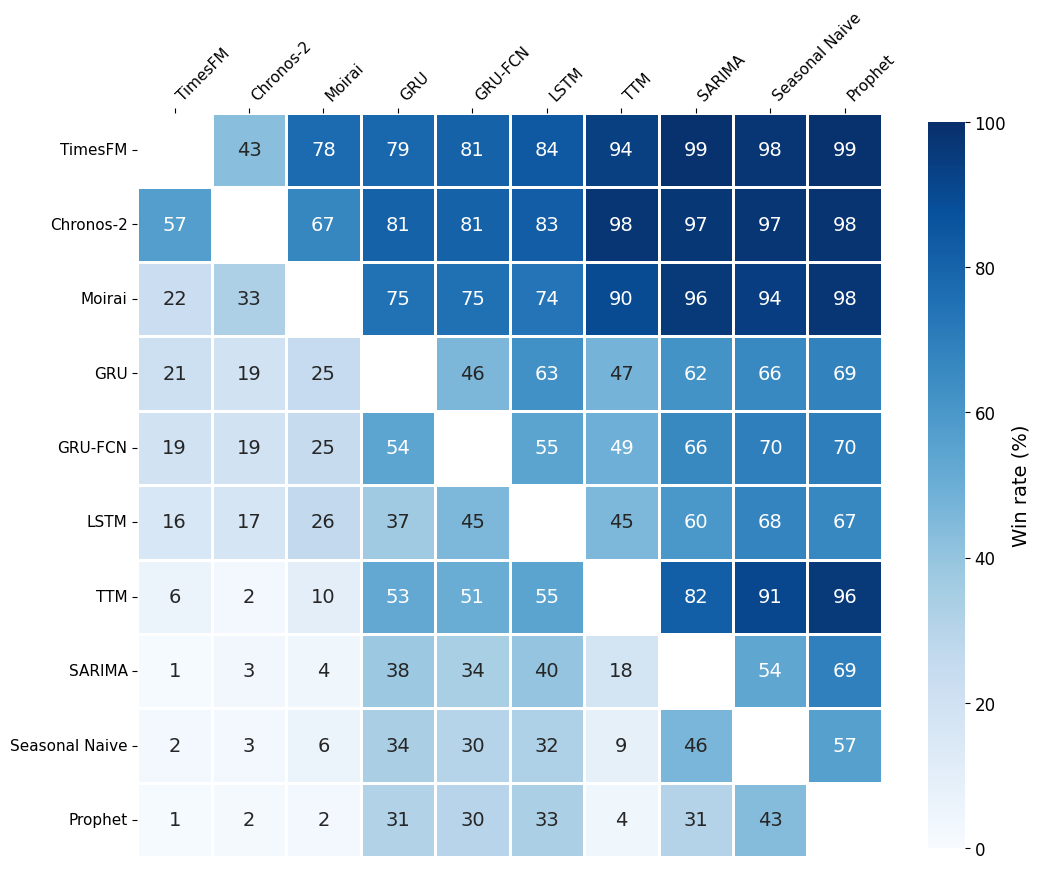

In [13]:
df_pooled = pd.concat([results[c] for c in ALL_CONFIGS], ignore_index=True)
df_pooled["model"] = pd.Categorical(
    df_pooled["model"],
    categories=[m for m in MODEL_ORDER if m in df_pooled["model"].unique()],
    ordered=True,
)

plot_pairwise_heatmap(
    df_pooled, METRIC, base_dir=GRAPH_DIR / "pooled",
    title="Pairwise Win Rate (%) — MASE — All Configs Pooled\n(cell[A,B] = % of series where row A < column B)",
)

## 9. Pairwise Win Rate (Per Config)

In [14]:
for config in ALL_CONFIGS:
    label = CONFIG_META[config]["label"]
    title = (
        f"Pairwise Win Rate (%) — MASE — {label}\n"
        f"(cell[A,B] = % of series where row A < column B)"
    )
    plot_pairwise_heatmap(results[config], METRIC, base_dir=GRAPH_DIR / config, title=title)

Pairwise Win Rate (%) — MASE — 168/24 (hourly)
(cell[A,B] = % of series where row A < column B)
Saved: result_exploration/graphs/h_168_24/mase/pairwise_heatmap.pdf
Pairwise Win Rate (%) — MASE — 744/168 (hourly)
(cell[A,B] = % of series where row A < column B)
Saved: result_exploration/graphs/h_744_168/mase/pairwise_heatmap.pdf
Pairwise Win Rate (%) — MASE — 288/144 (10min)
(cell[A,B] = % of series where row A < column B)
Saved: result_exploration/graphs/m_288_144/mase/pairwise_heatmap.pdf
Pairwise Win Rate (%) — MASE — 1008/144 (10min)
(cell[A,B] = % of series where row A < column B)
Saved: result_exploration/graphs/m_1008_144/mase/pairwise_heatmap.pdf


## 10. Pairwise Skill Score (Pooled)

All series from all configs pooled. Positive = row model outperforms column model.

Pairwise Skill Score (%) — MASE — All Configs Pooled
Positive = row model outperforms column model
Saved: result_exploration/graphs/pooled/pairwise_skill.pdf


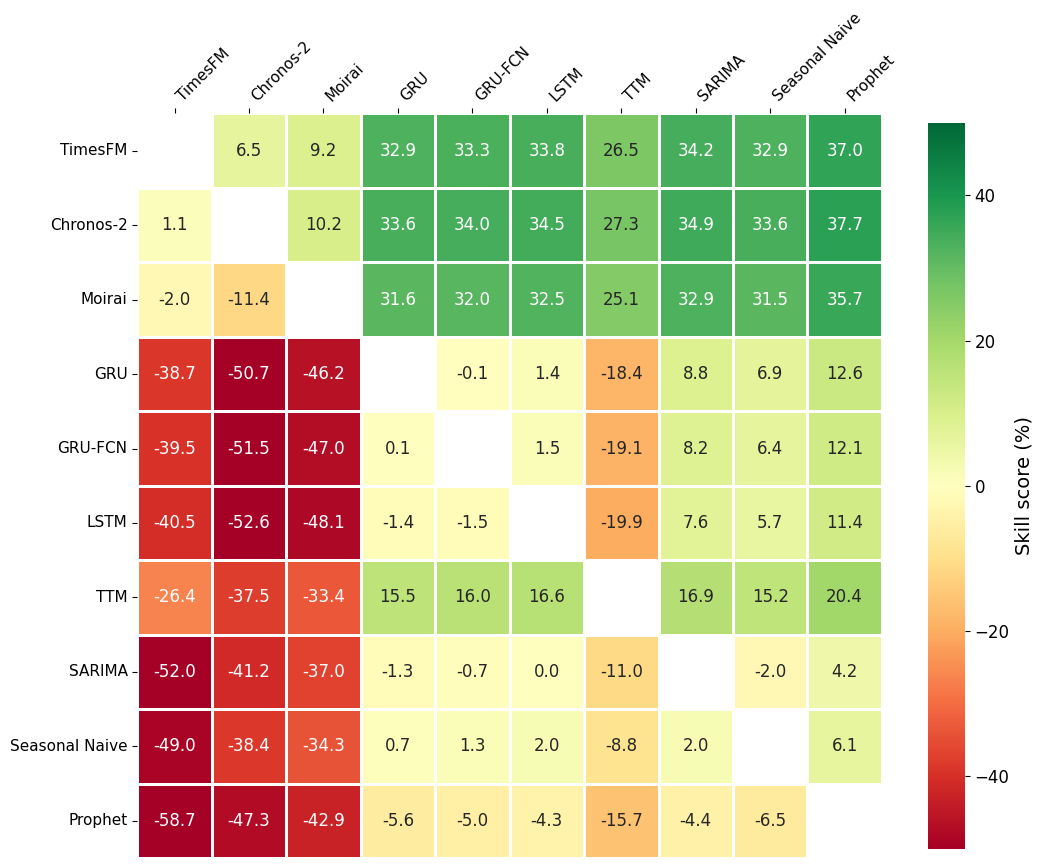

In [15]:
df_pooled_skill = pd.concat([results[c] for c in ALL_CONFIGS], ignore_index=True)
df_pooled_skill["model"] = pd.Categorical(
    df_pooled_skill["model"],
    categories=[m for m in MODEL_ORDER if m in df_pooled_skill["model"].unique()],
    ordered=True,
)

skill_matrix = compute_pairwise_skill(df_pooled_skill, METRIC) * 100
display_m = skill_matrix.copy()
display_m.index = [MODEL_LABELS.get(m, m) for m in display_m.index]
display_m.columns = [MODEL_LABELS.get(m, m) for m in display_m.columns]

n = len(display_m)
cell_size = 0.85
side = max(cell_size * n + 2.5, 7)
fig, ax = plt.subplots(figsize=(side, side))

sns.heatmap(
    display_m.astype(float), annot=True, fmt=".1f", annot_kws={"size": 12},
    cmap="RdYlGn", center=0, vmin=-50, vmax=50,
    linewidths=0.8, linecolor="white", square=True, ax=ax,
    cbar_kws={"label": "Skill score (%)", "shrink": 0.7},
)
ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="left", fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)
ax.set_title("")

print("Pairwise Skill Score (%) — MASE — All Configs Pooled\nPositive = row model outperforms column model")

fig.tight_layout()
out = GRAPH_DIR / "pooled" / "pairwise_skill.pdf"
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, bbox_inches="tight")
print(f"Saved: {out}")
plt.show()

## 11. Pairwise Skill Score (Per Config, Per Benchmark)

$S_{jk} = 1 - \sqrt[R]{\prod_{r=1}^{R} \text{clip}\left(\frac{E_{rj}}{E_{rk}};\, \ell,\, u\right)}$ with $\ell = 10^{-2}$, $u = 100$. Positive = row model outperforms column model.

In [16]:
for config in ALL_CONFIGS:
    label = CONFIG_META[config]["label"]
    df = results[config]

    for bench in BENCHMARKS:
        bench_df = df[df["benchmark"] == bench]
        if bench_df.empty:
            continue
        skill_matrix = compute_pairwise_skill(bench_df, METRIC) * 100
        display_m = skill_matrix.copy()
        display_m.index = [MODEL_LABELS.get(m, m) for m in display_m.index]
        display_m.columns = [MODEL_LABELS.get(m, m) for m in display_m.columns]

        print(f"\n{BENCH_LABELS.get(bench, bench)} — {label}")
        display(
            display_m.astype(float).style
            .format("{:.1f}", na_rep="—")
            .background_gradient(cmap="RdYlGn", vmin=-50, vmax=50, axis=None)
        )


Drift — 168/24 (hourly)


,TimesFM,Chronos-2,Moirai,GRU,GRU-FCN,LSTM,TTM,SARIMA,Seasonal Naive,Prophet
TimesFM,—,-3.4,1.0,10.3,11.6,14.8,2.4,34.9,29.9,32.1
Chronos-2,3.3,—,4.3,13.2,14.5,17.5,5.6,37.1,32.2,34.3
Moirai,-1.0,-4.5,—,9.3,10.7,13.9,1.4,34.3,29.2,31.4
GRU,-11.5,-15.2,-10.3,—,1.5,5.0,-8.8,27.5,21.9,24.3
GRU-FCN,-13.2,-17.0,-12.0,-1.5,—,3.5,-10.5,26.4,20.7,23.1
LSTM,-17.3,-21.3,-16.1,-5.3,-3.7,—,-14.5,23.7,17.8,20.3
TTM,-2.5,-5.9,-1.4,8.1,9.5,12.7,—,33.3,28.2,30.4
SARIMA,-53.7,-58.9,-52.1,-37.9,-35.8,-31.0,-50.0,—,-7.7,-4.4
Seasonal Naive,-42.7,-47.5,-41.2,-28.0,-26.1,-21.6,-39.3,7.2,—,3.1
Prophet,-47.2,-52.2,-45.7,-32.1,-30.1,-25.5,-43.7,4.2,-3.2,—



Seasonal — 168/24 (hourly)


,TimesFM,Chronos-2,Moirai,GRU,GRU-FCN,LSTM,TTM,SARIMA,Seasonal Naive,Prophet
TimesFM,—,-6.6,2.9,13.0,7.1,14.7,4.2,34.9,29.4,34.3
Chronos-2,6.2,—,8.9,18.4,12.9,20.0,10.2,39.0,33.8,38.4
Moirai,-3.0,-9.8,—,10.4,4.4,12.1,1.3,33.0,27.3,32.4
GRU,-14.9,-22.5,-11.6,—,-6.7,2.0,-10.1,25.2,18.9,24.5
GRU-FCN,-7.7,-14.8,-4.6,6.3,—,8.1,-3.1,29.9,24.0,29.3
LSTM,-17.2,-24.9,-13.8,-2.0,-8.8,—,-12.3,23.7,17.3,23.0
TTM,-4.4,-11.3,-1.4,9.1,3.1,10.9,—,32.1,26.3,31.4
SARIMA,-53.6,-63.8,-49.2,-33.7,-42.7,-31.1,-47.2,—,-8.4,-0.9
Seasonal Naive,-41.7,-51.1,-37.6,-23.4,-31.6,-20.9,-35.8,7.7,—,6.9
Prophet,-52.2,-62.3,-47.8,-32.5,-41.4,-29.9,-45.8,0.9,-7.4,—



Periodic Spaces — 168/24 (hourly)


...

,TimesFM,Chronos-2,Moirai,GRU,GRU-FCN,LSTM,TTM,SARIMA,Seasonal Naive,Prophet
TimesFM,—,60.7,59.4,58.6,60.5,58.6,72.5,30.9,43.6,53.1
Chronos-2,-1.7,—,58.9,58.1,60.0,58.1,72.1,29.7,42.7,52.3
Moirai,2.4,-143.1,—,59.4,61.3,59.4,73.0,32.5,45.0,54.2
GRU,4.7,-138.4,-146.4,—,-6.1,2.4,-67.2,34.2,46.3,55.3
GRU-FCN,-1.1,-150.0,-158.3,5.7,—,8.0,-75.3,30.1,43.0,52.5
LSTM,4.7,-138.4,-146.4,-2.5,-8.7,—,-67.2,34.2,46.3,55.3
TTM,-58.5,-258.2,-270.2,40.2,43.0,40.2,—,-9.5,10.7,25.6
SARIMA,-44.7,47.2,45.4,44.4,47.0,44.4,63.0,—,18.4,32.1
Seasonal Naive,-77.4,37.9,35.8,34.5,37.6,34.5,56.4,-22.6,—,16.7
Prophet,-113.0,28.1,25.7,24.2,27.7,24.2,49.6,-47.2,-20.1,—



Workers — 1008/144 (10min)


,TimesFM,Chronos-2,Moirai,GRU,GRU-FCN,LSTM,TTM,SARIMA,Seasonal Naive,Prophet
TimesFM,—,-1.4,-2.4,-4.9,7.9,-4.9,40.3,45.0,45.3,56.2
Chronos-2,1.4,—,-0.9,-3.4,9.2,-3.4,41.1,45.7,46.1,56.8
Moirai,2.3,0.9,—,-2.5,10.0,-2.5,41.7,46.2,46.6,57.2
GRU,4.7,3.3,2.4,—,12.2,0.0,43.1,47.5,47.9,58.3
GRU-FCN,-8.6,-10.1,-11.2,-13.9,—,-13.9,35.2,40.2,40.6,52.4
LSTM,4.7,3.3,2.4,-0.0,12.2,—,43.1,47.5,47.9,58.3
TTM,-67.5,-69.9,-71.5,-75.7,-54.3,-75.7,—,7.8,8.4,26.6
SARIMA,-81.7,-84.3,-86.0,-90.7,-67.3,-90.7,-8.5,—,0.6,20.4
Seasonal Naive,-82.9,-85.5,-87.2,-91.9,-68.4,-91.8,-9.2,-0.6,—,19.9
Prophet,-128.4,-131.6,-133.8,-139.6,-110.3,-139.6,-36.3,-25.7,-24.9,—



Random — 1008/144 (10min)


,TimesFM,Chronos-2,Moirai,GRU,GRU-FCN,LSTM,TTM,SARIMA,Seasonal Naive,Prophet
TimesFM,—,0.1,0.5,4.7,11.0,8.9,27.0,34.0,38.6,37.8
Chronos-2,-0.1,—,0.4,4.6,10.9,8.9,27.0,33.9,38.6,37.8
Moirai,-0.5,-0.4,—,4.3,10.6,8.5,26.7,33.7,38.3,37.5
GRU,-4.9,-4.9,-4.5,—,6.6,4.4,23.4,30.7,35.6,34.7
GRU-FCN,-12.3,-12.2,-11.8,-7.0,—,-2.3,18.1,25.9,31.0,30.1
LSTM,-9.8,-9.7,-9.3,-4.6,2.2,—,19.9,27.5,32.6,31.7
TTM,-37.1,-37.0,-36.4,-30.6,-22.0,-24.8,—,9.5,15.8,14.8
SARIMA,-51.5,-51.4,-50.8,-44.4,-34.9,-38.0,-10.5,—,7.0,5.8
Seasonal Naive,-62.9,-62.8,-62.1,-55.2,-45.0,-48.3,-18.8,-7.5,—,-1.3
Prophet,-60.8,-60.7,-60.1,-53.2,-43.2,-46.4,-17.3,-6.1,1.3,—


## 12. Performance by Aggregation Level (Pooled)

Per model, per benchmark, per aggregation level: mean MASE, average rank, and skill score (%). Pooled across all configs. Benchmarks with a single aggregation level (Periodic Spaces, Workers) show only that row.

In [17]:
df_pool_agg = pd.concat(
    [results[c].assign(config=c) for c in ALL_CONFIGS], ignore_index=True
)

benchmarks = [b for b in BENCHMARKS if b in df_pool_agg["benchmark"].unique()]
agg_levels = [a for a in AGG_LEVEL_ORDER if a in df_pool_agg["agg_level"].unique()]
models = [m for m in MODEL_ORDER if m in df_pool_agg["model"].unique()]

avg_mase_agg = df_pool_agg.groupby(["model", "benchmark", "agg_level"])[METRIC].mean()
std_mase_agg = df_pool_agg.groupby(["model", "benchmark", "agg_level"])[METRIC].std()

rank_pivot = df_pool_agg.pivot_table(
    index=["config", "id", "agg_level", "benchmark"], columns="model", values=METRIC
)
ranks_per_series = rank_pivot.rank(axis=1)
ranks_per_series = ranks_per_series.reset_index()
avg_rank_agg = ranks_per_series.groupby(["benchmark", "agg_level"])[models].mean()

skill_agg = skill_score(df_pool_agg, METRIC, ["model", "benchmark", "agg_level"])
skill_pivot = skill_agg.pivot_table(index=["model"], columns=["benchmark", "agg_level"], values="skill_score")

rows = []
for model in models:
    for agg in agg_levels:
        row = {"model": MODEL_LABELS.get(model, model), "agg_level": agg}
        for bench in benchmarks:
            bl = BENCH_LABELS.get(bench, bench)
            try:
                m_val = avg_mase_agg.loc[(model, bench, agg)]
                s_val = std_mase_agg.loc[(model, bench, agg)]
                row[(bl, "MASE")] = f"{m_val:.3f} ± {s_val:.3f}"
            except KeyError:
                row[(bl, "MASE")] = "—"
            try:
                row[(bl, "Rank")] = avg_rank_agg.loc[(bench, agg), model]
            except KeyError:
                row[(bl, "Rank")] = np.nan
            try:
                row[(bl, "Skill %")] = skill_pivot.loc[model, (bench, agg)] * 100
            except KeyError:
                row[(bl, "Skill %")] = np.nan
        rows.append(row)

result = pd.DataFrame(rows)
result = result.set_index(["model", "agg_level"])
result.columns = pd.MultiIndex.from_tuples(
    [(c[0], c[1]) for c in result.columns], names=["Benchmark", "Metric"]
)

def _model_group_borders(df):
    styles = pd.DataFrame("", index=df.index, columns=df.columns)
    n_agg = len(agg_levels)
    for i in range(n_agg - 1, len(df), n_agg):
        styles.iloc[i] = "border-bottom: 3px solid #60a5fa"
    return styles

display(
    result.style
    .format(
        {col: "{:.2f}" if col[1] == "Rank" else "{:.1f}" if col[1] == "Skill %" else "{}"
         for col in result.columns},
        na_rep="—",
    )
    .apply(_model_group_borders, axis=None)
)

Saved: result_exploration/graphs/pooled/mase/agg_level_breakdown.pdf


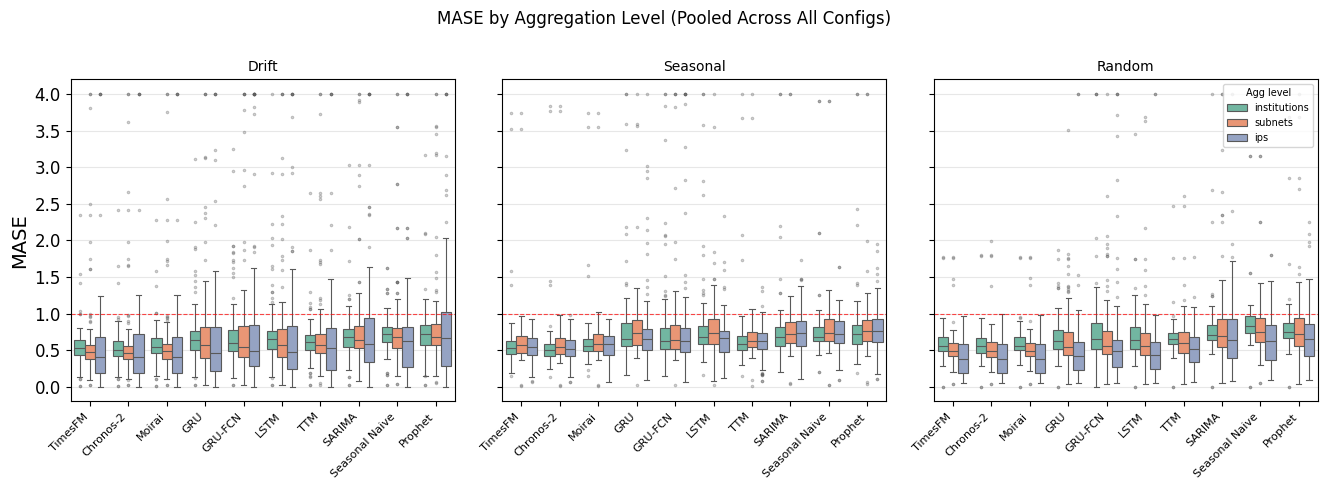

In [18]:
df_pool_box = pd.concat([results[c] for c in ALL_CONFIGS], ignore_index=True)
df_pool_box["model"] = pd.Categorical(
    df_pool_box["model"],
    categories=[m for m in MODEL_ORDER if m in df_pool_box["model"].unique()],
    ordered=True,
)
df_pool_box["benchmark"] = pd.Categorical(
    df_pool_box["benchmark"],
    categories=[b for b in BENCHMARKS if b in df_pool_box["benchmark"].unique()],
    ordered=True,
)
df_pool_box["agg_level"] = pd.Categorical(
    df_pool_box["agg_level"],
    categories=[a for a in AGG_LEVEL_ORDER if a in df_pool_box["agg_level"].unique()],
    ordered=True,
)
plot_agg_level_breakdown(df_pool_box, METRIC, base_dir=GRAPH_DIR / "pooled", title="MASE by Aggregation Level (Pooled Across All Configs)")

## 13. Inference Time (Per Config)

In [19]:
for config in ALL_CONFIGS:
    label = CONFIG_META[config]["label"]
    timing = load_timing_data(EXPERIMENT_CONFIGS[config])

    plot_speed_comparison(timing, base_dir=GRAPH_DIR / config, title=f"Inference Speed — {label}")

    timing["total"] = timing["tune_time"] + timing["predict_time"]
    timing_display = timing.copy()
    timing_display.index = [MODEL_LABELS.get(m, m) for m in timing_display["model"]]
    timing_display = timing_display.drop(columns=["model"])
    timing_display.columns = ["Tune (s/100pts)", "Predict (s/100pts)", "Total (s/100pts)"]
    display(timing_display.style.format(precision=3))

Saved: result_exploration/graphs/h_168_24/speed_comparison.pdf


,Tune (s/100pts),Predict (s/100pts),Total (s/100pts)
TimesFM,0.000,0.023,0.023
Chronos-2,0.000,0.021,0.021
Moirai,0.000,0.012,0.012
GRU,0.012,0.002,0.014
GRU-FCN,0.052,0.005,0.057
LSTM,0.013,0.003,0.017
TTM,0.000,0.034,0.034
SARIMA,0.000,2.195,2.195
Seasonal Naive,0.000,0.000,0.000
Prophet,0.000,0.353,0.353


Saved: result_exploration/graphs/h_744_168/speed_comparison.pdf


,Tune (s/100pts),Predict (s/100pts),Total (s/100pts)
TimesFM,0.000,0.019,0.019
Chronos-2,0.000,0.005,0.005
Moirai,0.000,0.009,0.009
GRU,0.004,0.001,0.005
GRU-FCN,0.004,0.001,0.005
LSTM,0.006,0.002,0.008
TTM,0.000,0.006,0.006
SARIMA,0.000,1.238,1.238
Seasonal Naive,0.000,0.000,0.000
Prophet,0.000,0.129,0.129


Saved: result_exploration/graphs/m_288_144/speed_comparison.pdf


,Tune (s/100pts),Predict (s/100pts),Total (s/100pts)
TimesFM,0.000,0.003,0.003
Chronos-2,0.000,0.002,0.002
Moirai,0.000,0.003,0.003
GRU,0.002,0.000,0.003
GRU-FCN,0.005,0.001,0.006
LSTM,0.003,0.001,0.004
TTM,0.000,0.003,0.003
SARIMA,0.000,0.179,0.179
Seasonal Naive,0.000,0.000,0.000
Prophet,0.000,0.069,0.069


Saved: result_exploration/graphs/m_1008_144/speed_comparison.pdf


,Tune (s/100pts),Predict (s/100pts),Total (s/100pts)
TimesFM,0.000,0.002,0.002
Chronos-2,0.000,0.003,0.003
Moirai,0.000,0.003,0.003
GRU,0.003,0.001,0.004
GRU-FCN,0.005,0.001,0.006
LSTM,0.006,0.002,0.008
TTM,0.000,0.002,0.002
SARIMA,0.000,0.504,0.504
Seasonal Naive,0.000,0.000,0.000
Prophet,0.000,0.162,0.162


## 14. Easiest / Hardest Series (Per Config)

Per-series raw MASE sorted by average across all models. Lowest = easiest, highest = hardest.

In [20]:
for config in ALL_CONFIGS:
    label = CONFIG_META[config]["label"]
    df = results[config]

    baseline_mase = df.loc[df["model"] == BASELINE, ["id", "agg_level", "benchmark", METRIC]]
    nonzero_ids = baseline_mase[baseline_mase[METRIC] > 0][["id", "agg_level", "benchmark"]]
    df_filtered = df.merge(nonzero_ids, on=["id", "agg_level", "benchmark"])

    pivot = df_filtered.pivot_table(index=["id", "agg_level", "benchmark"], columns="model", values=METRIC)
    pivot.columns = [MODEL_LABELS.get(m, m) for m in pivot.columns]
    pivot["avg_mase"] = pivot.mean(axis=1)
    pivot = pivot.sort_values("avg_mase", ascending=True).reset_index()

    fmt = {c: "{:.3f}" for c in pivot.columns if c not in ["id", "agg_level", "benchmark"]}

    easiest = pivot.head(20)
    hardest = pivot.tail(20).sort_values("avg_mase", ascending=False)

    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")

    print("\n20 Easiest Series (lowest avg MASE)")
    display(
        easiest.style
        .format(fmt, na_rep="—")
        .background_gradient(cmap="RdYlGn_r", subset=["avg_mase"])
        .hide(axis="index")
    )
    display(easiest["benchmark"].map(BENCH_LABELS).value_counts().rename("count").to_frame())

    print("\n20 Hardest Series (highest avg MASE)")
    display(
        hardest.style
        .format(fmt, na_rep="—")
        .background_gradient(cmap="RdYlGn_r", subset=["avg_mase"])
        .hide(axis="index")
    )
    display(hardest["benchmark"].map(BENCH_LABELS).value_counts().rename("count").to_frame())


  168/24 (hourly)

20 Easiest Series (lowest avg MASE)


id,agg_level,benchmark,TimesFM,Chronos-2,Moirai,GRU,GRU-FCN,LSTM,TTM,SARIMA,Seasonal Naive,Prophet,avg_mase
264,institutions,random,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.001,0.000,0.000,0.000
242764,ips,drift,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
334600,ips,periodic_spaces,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.004,0.002,0.003,0.002
1774,ips,drift,0.009,0.008,0.009,0.017,0.019,0.018,0.009,0.010,0.012,0.010,0.012
1368,ips,drift,0.016,0.015,0.016,0.018,0.018,0.026,0.016,0.029,0.025,0.025,0.020
391,subnets,seasonal,0.017,0.018,0.017,0.020,0.020,0.022,0.017,0.045,0.028,0.040,0.025
733725,ips,workers,0.023,0.024,0.023,0.023,0.023,0.024,0.023,0.100,0.046,0.062,0.037
48,subnets,drift,0.024,0.024,0.025,0.026,0.027,0.026,0.025,0.096,0.045,0.059,0.038
300547,ips,drift,0.033,0.032,0.032,0.034,0.036,0.034,0.033,0.099,0.057,0.068,0.046
11204,ips,periodic_spaces,0.015,0.016,0.015,0.015,0.348,0.015,0.015,0.053,0.029,0.046,0.057


,count
benchmark,
Drift,8
Random,5
Periodic Spaces,3
Seasonal,2
Workers,2



20 Hardest Series (highest avg MASE)


id,agg_level,benchmark,TimesFM,Chronos-2,Moirai,GRU,GRU-FCN,LSTM,TTM,SARIMA,Seasonal Naive,Prophet,avg_mase
471658,ips,random,0.919,0.936,0.894,0.862,0.864,0.862,0.938,155.388,1.446,1.975,16.508
355332,ips,periodic_spaces,9.131,10.173,8.933,8.811,10.958,8.806,8.892,17.205,12.171,13.205,10.828
11254,ips,drift,4.574,4.634,4.581,4.533,4.532,4.535,4.559,10.616,7.423,9.252,5.924
204,institutions,seasonal,3.527,3.764,3.545,3.591,3.841,3.570,3.671,4.246,3.902,4.867,3.852
451,subnets,seasonal,3.527,3.764,3.545,3.563,3.816,3.545,3.671,4.246,3.902,4.867,3.845
280,subnets,drift,2.504,2.666,2.572,3.144,3.476,3.130,2.611,2.889,3.552,3.550,3.009
277,institutions,random,1.753,1.791,1.764,1.743,1.791,1.743,1.755,5.278,3.159,3.690,2.447
542,subnets,random,1.753,1.791,1.764,1.744,1.784,1.742,1.755,5.278,3.159,3.690,2.446
43,subnets,drift,1.741,1.745,1.744,1.730,1.732,1.730,1.734,3.918,2.775,3.453,2.230
217,institutions,seasonal,1.576,1.393,1.658,2.081,1.957,2.623,1.730,2.194,2.103,2.212,1.953


...

id,agg_level,benchmark,TimesFM,Chronos-2,Moirai,GRU,GRU-FCN,LSTM,TTM,SARIMA,Seasonal Naive,Prophet,avg_mase
242764,ips,drift,0.000,0.000,0.000,0.000,0.001,0.000,0.000,0.000,0.000,0.000,0.000
137398,ips,periodic_spaces,0.003,0.008,0.004,0.003,0.003,0.003,0.005,0.005,0.007,0.009,0.005
1368,ips,drift,0.011,0.011,0.011,0.015,0.023,0.016,0.018,0.017,0.021,0.021,0.017
223496,ips,periodic_spaces,0.012,0.011,0.012,0.011,0.011,0.011,0.023,0.026,0.022,0.032,0.017
1774,ips,drift,0.013,0.012,0.013,0.025,0.028,0.025,0.024,0.014,0.017,0.030,0.020
202,institutions,drift,0.017,0.017,0.017,0.027,0.020,0.025,0.022,0.023,0.029,0.025,0.022
849573,ips,periodic_spaces,0.026,0.026,0.026,0.025,0.025,0.025,0.050,0.057,0.050,0.069,0.038
119,subnets,random,0.037,0.037,0.036,0.042,0.040,0.043,0.042,0.047,0.054,0.046,0.042
120,ips,drift,0.034,0.035,0.035,0.034,0.034,0.034,0.074,0.063,0.058,0.093,0.049
324745,ips,periodic_spaces,0.040,0.041,0.041,0.040,0.040,0.040,0.070,0.058,0.074,0.084,0.053


,count
benchmark,
Drift,8
Periodic Spaces,4
Random,4
Seasonal,2
Workers,2



20 Hardest Series (highest avg MASE)


id,agg_level,benchmark,TimesFM,Chronos-2,Moirai,GRU,GRU-FCN,LSTM,TTM,SARIMA,Seasonal Naive,Prophet,avg_mase
51,subnets,drift,20.136,18.258,19.526,30.313,34.123,31.996,17.983,26.128,19.488,21.448,23.940
11254,ips,drift,4.582,4.594,4.583,4.520,4.520,4.520,6.382,11.562,7.696,10.389,6.335
67,subnets,drift,1.604,1.652,1.658,2.379,3.782,2.224,1.672,2.018,2.167,1.800,2.096
565727,ips,drift,1.160,1.168,1.165,1.160,1.159,1.258,1.874,2.461,2.038,2.621,1.606
293673,ips,periodic_spaces,1.551,1.204,1.203,1.179,1.185,1.179,1.916,1.626,2.136,2.438,1.562
330940,ips,workers,1.115,1.119,1.119,1.097,1.097,1.097,1.704,1.919,1.885,2.905,1.506
29898,ips,workers,1.017,1.013,1.011,0.995,1.003,0.995,1.673,2.166,1.847,2.228,1.395
26,institutions,drift,1.042,0.933,1.013,1.917,1.918,2.028,1.145,1.197,1.334,1.044,1.357
130,subnets,seasonal,0.899,0.851,1.022,0.978,2.716,1.023,1.005,1.044,1.323,1.578,1.244
5117,ips,seasonal,0.927,0.926,0.933,0.922,0.930,0.931,1.364,1.291,1.642,1.849,1.171


,count
benchmark,
Drift,9
Seasonal,5
Workers,3
Random,2
Periodic Spaces,1
